In [ ]:
# ============================================
# 🔧 Install & import dependencies
# ============================================
!pip install transformers torch accelerate

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

In [ ]:
# ============================================
# 🤖 Load FinBERT
# ============================================
model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

print("✅ FinBERT loaded successfully")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Device set to use cpu


✅ FinBERT loaded successfully


In [ ]:
# ============================================
# 🔧 Helper functions
# ============================================

def finbert_label(text):
    """
    Apply FinBERT to a single text
    """
    if not isinstance(text, str) or text.strip() == "":
        return "neutral", 0.0

    result = sentiment_pipeline(text[:512])[0]
    return result["label"].lower(), result["score"]


def label_to_score(label):
    """
    Convert sentiment label → numerical score
    """
    if label == "positive":
        return 1
    elif label == "negative":
        return -1
    else:
        return 0


In [ ]:
# ============================================
# 📂 Load TITLE-ONLY data
# ============================================
title_only_path = "/content/HN_AMD_Title_Only.xlsx"

df_title = pd.read_excel(title_only_path)

print(f"Loaded {len(df_title)} title-only rows")
df_title.head()


Loaded 2826 title-only rows


,keyword,title,hn_link,created_at_i,date,post
0,amd,"Run CUDA, unmodified, on AMD GPUs",https://news.ycombinator.com/item?id=40970560,1721070307,2024-07-15,NaN
1,amd,I helped fix sleep-wake hangs on Linux with AM...,https://news.ycombinator.com/item?id=43071983,1739742123,2025-02-16,NaN
2,amd,AMD outsells Intel in the datacenter space,https://news.ycombinator.com/item?id=42054449,1730834835,2024-11-05,NaN
3,amd,AMD to buy Silo AI for $665M,https://news.ycombinator.com/item?id=40926648,1720617975,2024-07-10,NaN
4,amd,"AMD signs AI chip-supply deal with OpenAI, giv...",https://news.ycombinator.com/item?id=45490549,1759753079,2025-10-06,NaN


In [ ]:
# ============================================
# 🤖 FinBERT inference (TITLE ONLY)
# ============================================
labels = []
scores = []

for i, row in df_title.iterrows():
    label, confidence = finbert_label(row["title"])
    labels.append(label)
    scores.append(label_to_score(label))

df_title["finbert_label"] = labels
df_title["sentiment_score"] = scores

print("✅ FinBERT labeling completed (title-only)")


✅ FinBERT labeling completed (title-only)


In [ ]:
# ============================================
# 📊 Daily sentiment (TITLE ONLY)
# ============================================
df_title["date"] = pd.to_datetime(df_title["date"])

daily_title_sentiment = (
    df_title
    .groupby("date")["sentiment_score"]
    .mean()
    .reset_index()
    .rename(columns={"sentiment_score": "daily_sentiment"})
)

daily_title_sentiment.head()


,date,daily_sentiment
0,2024-07-01,0.000
1,2024-07-02,0.250
2,2024-07-03,0.000
3,2024-07-04,-0.500
4,2024-07-05,0.125


In [ ]:
# ============================================
# 💾 Save TITLE-ONLY outputs
# ============================================
df_title.to_excel(
    "/content/FinBERT_Title_Only_Labeled.xlsx",
    index=False
)

daily_title_sentiment.to_excel(
    "/content/Daily_Sentiment_Title_Only.xlsx",
    index=False
)

print("💾 Title-only files saved")


💾 Title-only files saved


In [ ]:
# ============================================
# 📂 Load TITLE + POST data
# ============================================
title_post_path = "/content/HN_AMD_Title_and_Post.xlsx"

df_post = pd.read_excel(title_post_path)

print(f"Loaded {len(df_post)} title+post rows")
df_post.head()


Loaded 2113 title+post rows


,keyword,title,hn_link,created_at_i,date,post
0,amd,We fine-tuned Llama 405B on AMD GPUs,https://news.ycombinator.com/item?id=41630913,1727127746,2024-09-23,"Hey HN, we recently fine-tuned the llama3.1 40..."
1,amd,Ask HN: Why hasn’t AMD made a viable CUDA alte...,https://news.ycombinator.com/item?id=43547309,1743518274,2025-04-01,I appreciate developing ROCm into something co...
2,amd,(ROCm) AMD-GPU-Boost: Unlock Full Performance ...,https://news.ycombinator.com/item?id=45000262,1755995948,2025-08-24,https://github.com/Painter3000/AMD-GPU-BOOST\n...
3,amd,"Ask HN: AMD employees, why is the RX 9070 ship...",https://news.ycombinator.com/item?id=42810784,1737697041,2025-01-24,This is the opposite of what everyone has been...
4,amd,Ask HN: What's Holding AMD Back?,https://news.ycombinator.com/item?id=42591871,1735958775,2025-01-04,Nvidia has an effective monopoly on the GPUs u...


In [ ]:
# ============================================
# 🧩 Combine title + post text
# ============================================
df_post["full_text"] = (
    df_post["title"].fillna("") + " " +
    df_post["post"].fillna("")
)


In [ ]:
# ============================================
# 🤖 FinBERT inference (TITLE + POST)
# ============================================
labels = []
scores = []

for i, row in df_post.iterrows():
    label, confidence = finbert_label(row["full_text"])
    labels.append(label)
    scores.append(label_to_score(label))

df_post["finbert_label"] = labels
df_post["sentiment_score"] = scores

print("✅ FinBERT labeling completed (title + post)")


✅ FinBERT labeling completed (title + post)


In [ ]:
# ============================================
# 📊 Daily sentiment (TITLE + POST)
# ============================================
df_post["date"] = pd.to_datetime(df_post["date"])

daily_post_sentiment = (
    df_post
    .groupby("date")["sentiment_score"]
    .mean()
    .reset_index()
    .rename(columns={"sentiment_score": "daily_sentiment"})
)

daily_post_sentiment.head()


,date,daily_sentiment
0,2024-07-01,0.0
1,2024-07-02,0.0
2,2024-07-04,0.0
3,2024-07-05,0.0
4,2024-07-06,0.0


In [ ]:
# ============================================
# 💾 Save TITLE + POST outputs
# ============================================
df_post.to_excel(
    "/content/FinBERT_Title_and_Post_Labeled.xlsx",
    index=False
)

daily_post_sentiment.to_excel(
    "/content/Daily_Sentiment_Title_and_Post.xlsx",
    index=False
)

print("💾 Title+Post files saved")


💾 Title+Post files saved


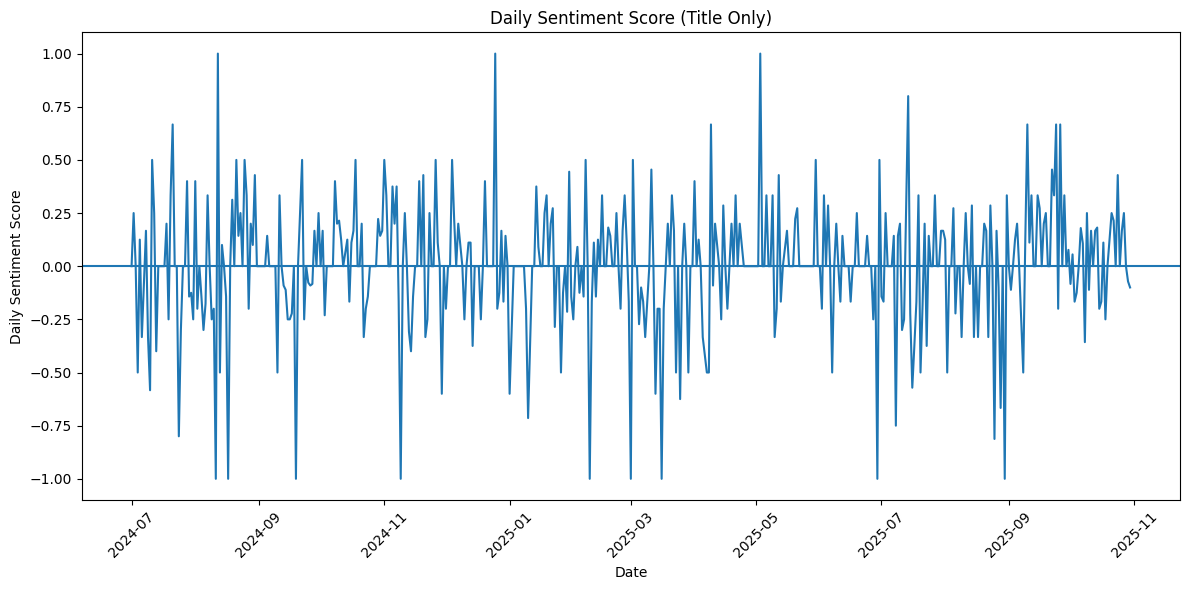

In [ ]:
# ============================================
# 📈 Plot Daily Sentiment Score (Title Only)
# ============================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    daily_title_sentiment["date"],
    daily_title_sentiment["daily_sentiment"]
)

plt.axhline(0)  # neutral baseline

plt.title("Daily Sentiment Score (Title Only)")
plt.xlabel("Date")
plt.ylabel("Daily Sentiment Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# 🔧 Rolling sentiment smoothing
# ============================================

# Make sure date is sorted
daily_title_sentiment = daily_title_sentiment.sort_values("date")

# Rolling averages
daily_title_sentiment["sentiment_7d"] = (
    daily_title_sentiment["daily_sentiment"]
    .rolling(window=7)
    .mean()
)

daily_title_sentiment["sentiment_14d"] = (
    daily_title_sentiment["daily_sentiment"]
    .rolling(window=14)
    .mean()
)

daily_title_sentiment.head(15)


,date,daily_sentiment,sentiment_7d,sentiment_14d
0,2024-07-01,0.000000,NaN,NaN
1,2024-07-02,0.250000,NaN,NaN
2,2024-07-03,0.000000,NaN,NaN
3,2024-07-04,-0.500000,NaN,NaN
4,2024-07-05,0.125000,NaN,NaN
5,2024-07-06,-0.333333,NaN,NaN
6,2024-07-08,0.166667,-0.041667,NaN
7,2024-07-09,-0.333333,-0.089286,NaN
8,2024-07-10,-0.583333,-0.208333,NaN
9,2024-07-11,0.500000,-0.136905,NaN


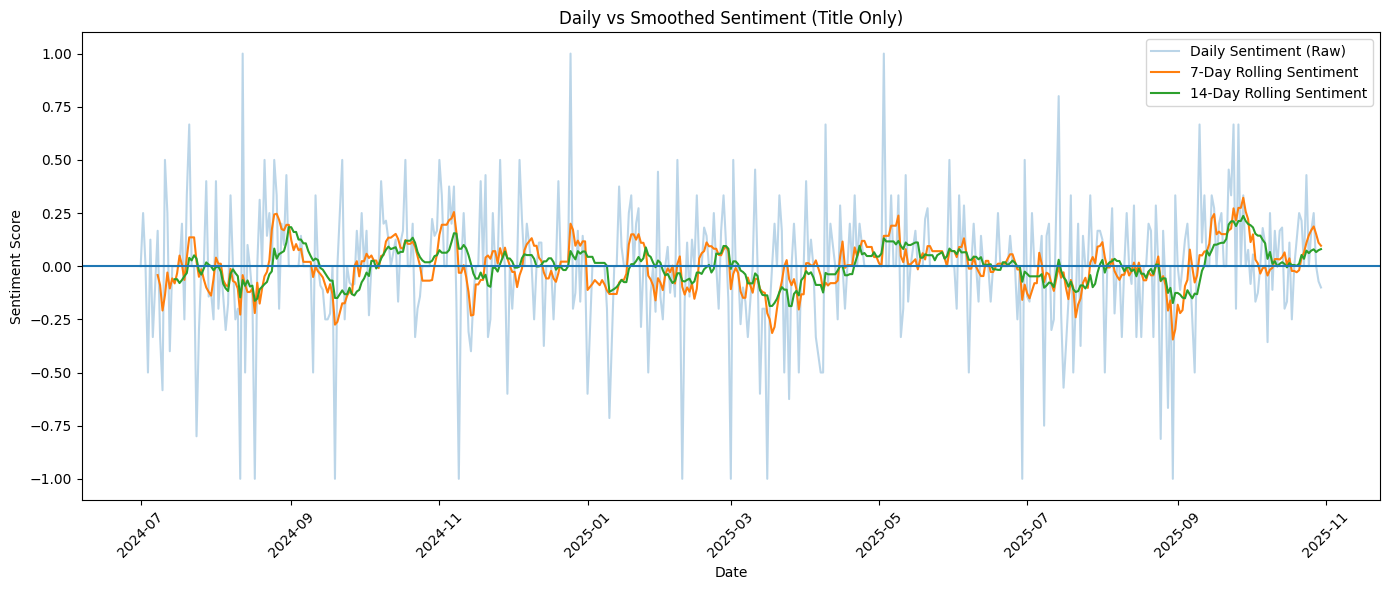

In [ ]:
# ============================================
# 📈 Plot raw vs smoothed sentiment
# ============================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Raw (faint)
plt.plot(
    daily_title_sentiment["date"],
    daily_title_sentiment["daily_sentiment"],
    alpha=0.3,
    label="Daily Sentiment (Raw)"
)

# Smoothed
plt.plot(
    daily_title_sentiment["date"],
    daily_title_sentiment["sentiment_7d"],
    label="7-Day Rolling Sentiment"
)

plt.plot(
    daily_title_sentiment["date"],
    daily_title_sentiment["sentiment_14d"],
    label="14-Day Rolling Sentiment"
)

plt.axhline(0)

plt.title("Daily vs Smoothed Sentiment (Title Only)")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


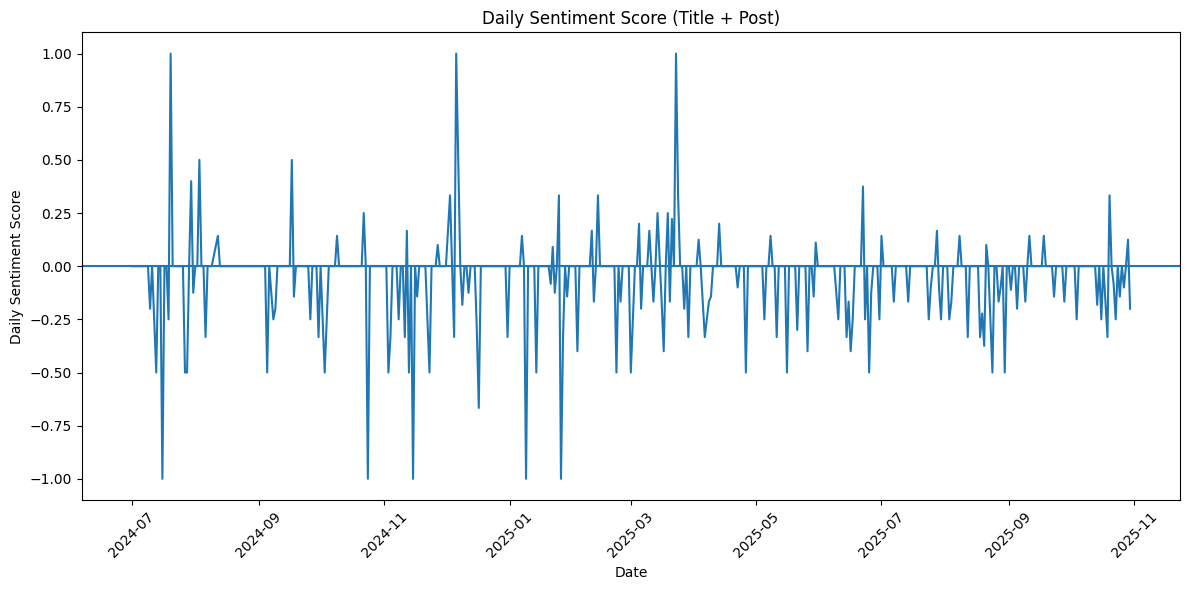

In [ ]:
# ============================================
# 📈 Plot Daily Sentiment Score (Title + Post)
# ============================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    daily_post_sentiment["date"],
    daily_post_sentiment["daily_sentiment"]
)

plt.axhline(0)

plt.title("Daily Sentiment Score (Title + Post)")
plt.xlabel("Date")
plt.ylabel("Daily Sentiment Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# 🔧 Rolling sentiment smoothing (Title + Post)
# ============================================

# Ensure sorted by date
daily_post_sentiment = daily_post_sentiment.sort_values("date")

# Rolling averages
daily_post_sentiment["sentiment_7d"] = (
    daily_post_sentiment["daily_sentiment"]
    .rolling(window=7)
    .mean()
)

daily_post_sentiment["sentiment_14d"] = (
    daily_post_sentiment["daily_sentiment"]
    .rolling(window=14)
    .mean()
)

daily_post_sentiment.head(15)


,date,daily_sentiment,sentiment_7d,sentiment_14d
0,2024-07-01,0.0,NaN,NaN
1,2024-07-02,0.0,NaN,NaN
2,2024-07-04,0.0,NaN,NaN
3,2024-07-05,0.0,NaN,NaN
4,2024-07-06,0.0,NaN,NaN
5,2024-07-07,0.0,NaN,NaN
6,2024-07-08,0.0,0.000000,NaN
7,2024-07-09,0.0,0.000000,NaN
8,2024-07-10,-0.2,-0.028571,NaN
9,2024-07-11,0.0,-0.028571,NaN


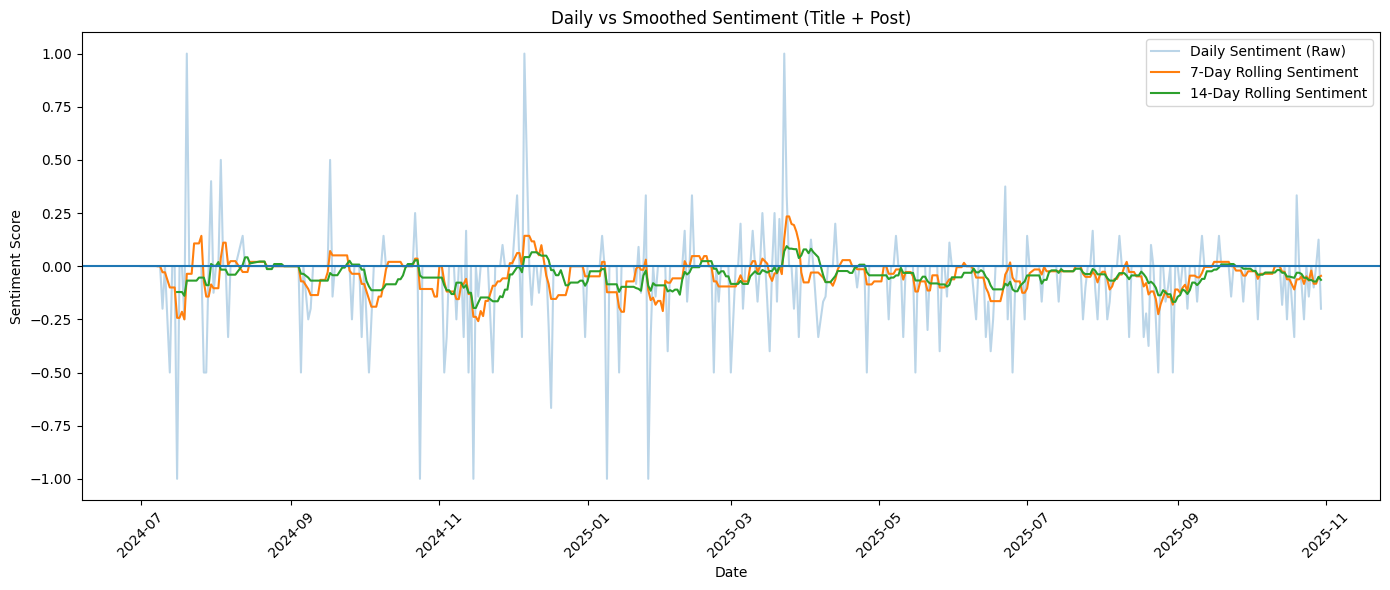

In [ ]:
# ============================================
# 📈 Plot raw vs smoothed sentiment (Title + Post)
# ============================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Raw sentiment
plt.plot(
    daily_post_sentiment["date"],
    daily_post_sentiment["daily_sentiment"],
    alpha=0.3,
    label="Daily Sentiment (Raw)"
)

# Smoothed sentiment
plt.plot(
    daily_post_sentiment["date"],
    daily_post_sentiment["sentiment_7d"],
    label="7-Day Rolling Sentiment"
)

plt.plot(
    daily_post_sentiment["date"],
    daily_post_sentiment["sentiment_14d"],
    label="14-Day Rolling Sentiment"
)

plt.axhline(0)

plt.title("Daily vs Smoothed Sentiment (Title + Post)")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


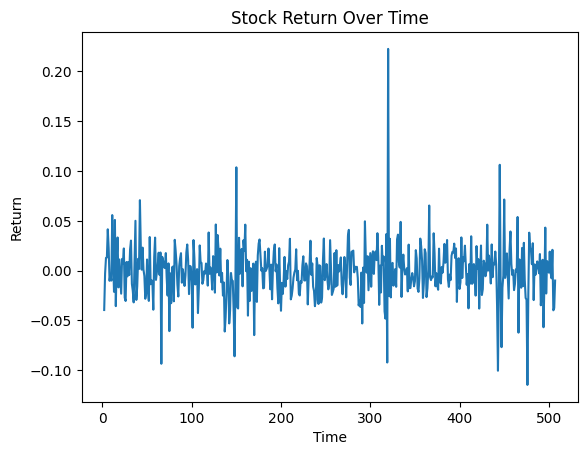

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
file_path = "/content/AMD_daily_2024_2026.csv"
df = pd.read_csv(file_path)

# Convert Open and Close to numeric (remove commas if any)
df["Open"] = pd.to_numeric(df["Open"].str.replace(",", ""), errors="coerce")
df["Close"] = pd.to_numeric(df["Close"].str.replace(",", ""), errors="coerce")

# Calculate return
df["Return"] = (df["Close"] - df["Open"]) / df["Open"]

# Drop rows with missing values
df = df.dropna(subset=["Return"])

# Plot the return
plt.figure()
plt.plot(df.index, df["Return"])
plt.xlabel("Time")
plt.ylabel("Return")
plt.title("Stock Return Over Time")
plt.show()


In [ ]:
# Find minimum length
n = min(
    len(df),
    len(daily_title_sentiment),
    len(daily_post_sentiment)
)

# Trim all to same length
returns = df["Return"].iloc[:n].reset_index(drop=True)
title_sent = daily_title_sentiment["daily_sentiment"].iloc[:n].reset_index(drop=True)
post_sent = daily_post_sentiment["daily_sentiment"].iloc[:n].reset_index(drop=True)



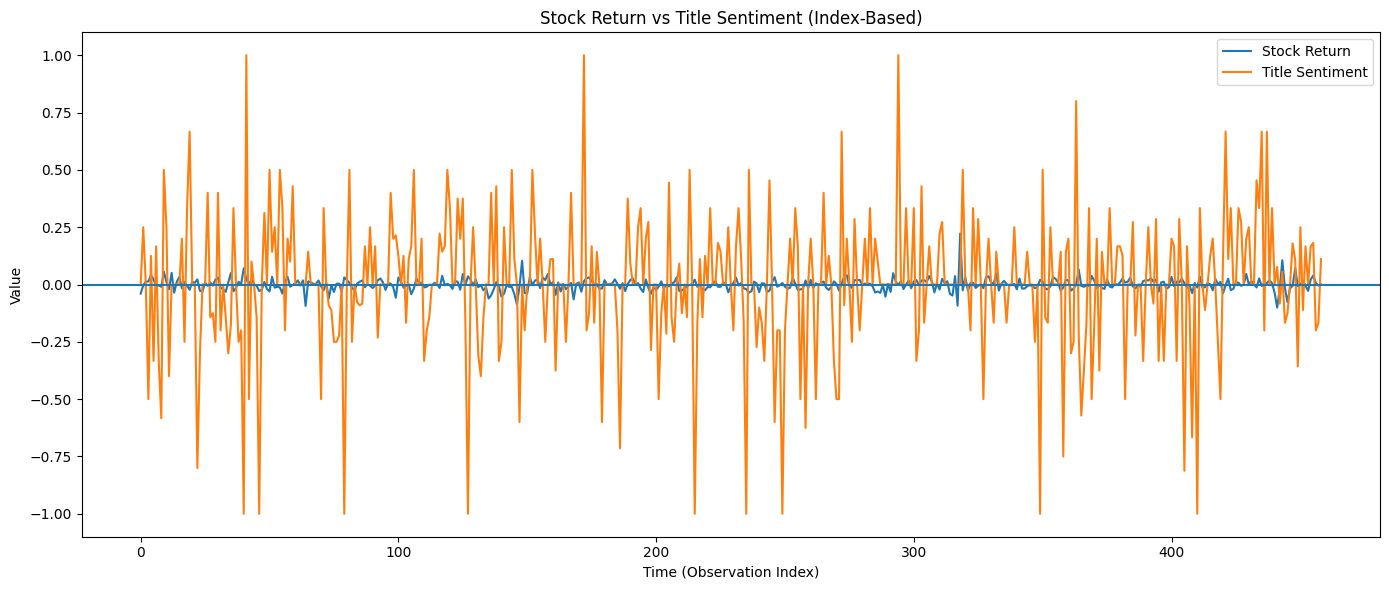

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(returns, label="Stock Return")
plt.plot(title_sent, label="Title Sentiment")

plt.axhline(0)
plt.title("Stock Return vs Title Sentiment (Index-Based)")
plt.xlabel("Time (Observation Index)")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()



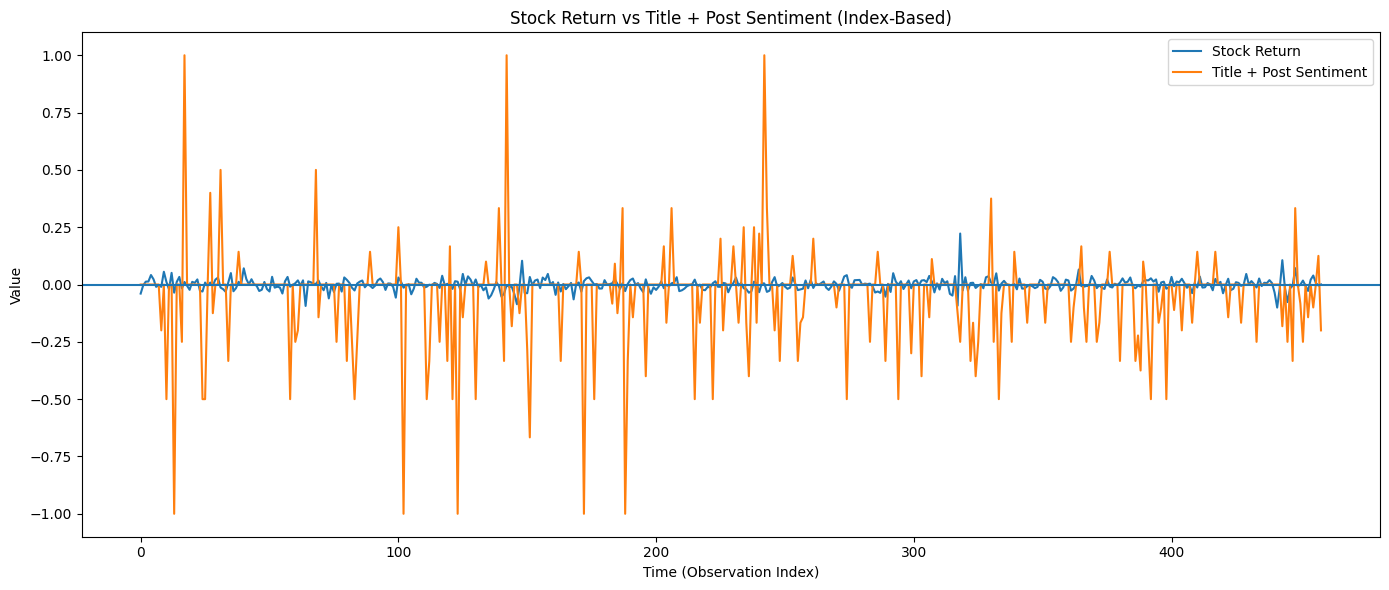

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(returns, label="Stock Return")
plt.plot(post_sent, label="Title + Post Sentiment")

plt.axhline(0)
plt.title("Stock Return vs Title + Post Sentiment (Index-Based)")
plt.xlabel("Time (Observation Index)")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


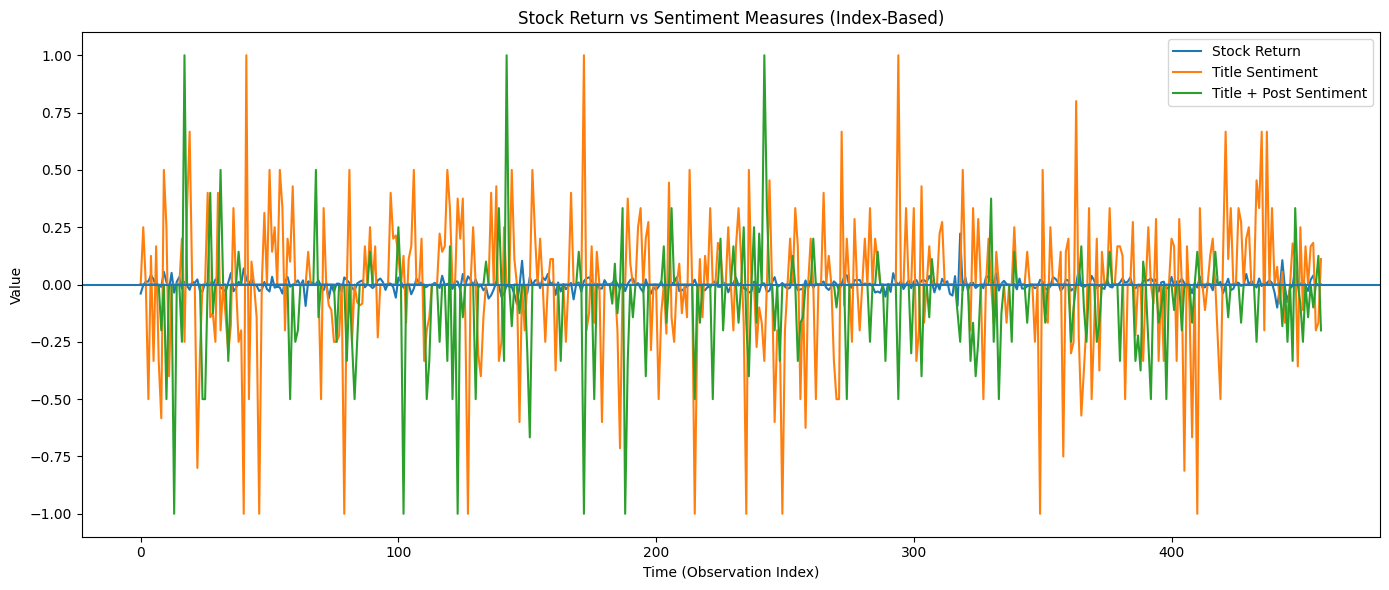

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(returns, label="Stock Return")
plt.plot(title_sent, label="Title Sentiment")
plt.plot(post_sent, label="Title + Post Sentiment")

plt.axhline(0)
plt.title("Stock Return vs Sentiment Measures (Index-Based)")
plt.xlabel("Time (Observation Index)")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()
